# Milestone 1: Data Exploration - Digital Music Reviews

This notebook explores the Amazon Reviews 2023 dataset (Digital Music Category). The goal is to understand the data, select fields for retrieval, preprocess text, and prepare documents in LangChain format for later pipeline stages.

**Data sources**
- Reviews: `Digital_Music.jsonl.gz` — user ratings, text, votes, timestamps  
- Metadata: `meta_Digital_Music.jsonl.gz` — product titles, descriptions, features, price

In [124]:
# imports
from pathlib import Path
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from langchain_core.documents import Document

### Configuration

In [125]:
DATA_DIR = Path("../data")
CATEGORY = "Digital_Music"
BASE_URL = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw"
REVIEWS_URL = f"{BASE_URL}/review_categories/{CATEGORY}.jsonl.gz"
META_URL    = f"{BASE_URL}/meta_categories/meta_{CATEGORY}.jsonl.gz"
RAW_DATA_PATH = str((DATA_DIR / "raw" ).resolve())
PROCESSED_DATA_PATH = str((DATA_DIR / "processed" ).resolve())

In [126]:
print(REVIEWS_URL)
print(META_URL)

https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/Digital_Music.jsonl.gz
https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/meta_categories/meta_Digital_Music.jsonl.gz


## Initialize an in-memory DB connection

In [127]:
conn = duckdb.connect()

### Schema Preview (remote — no download)

Before downloading, inspect the schema and a few rows directly from the remote `.jsonl.gz` files. DuckDB streams these without a full download.

In [128]:
head_reviews = conn.execute(f"SELECT * FROM read_json_auto('{REVIEWS_URL}') LIMIT 5").df()
head_reviews

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Nice,If i had a dollar for how many times I have pl...,[],B004RQ2IRG,B004RQ2IRG,AFUOYIZBU3MTBOLYKOJE5Z35MBDA,1618972613292,0,True
1,5.0,Excellent,awesome sound - cant wait to see them in perso...,[],B0026UZEI0,B0026UZEI0,AHGAOIZVODNHYMNCBV4DECZH42UQ,1308167525000,0,True
2,5.0,Great service,This is a great cd. Good music and plays well....,[],B0055JSYHC,B0055JSYHC,AFGEM6BXCYHUILEOA3P2ZYBEF2TA,1615838793006,0,True
3,1.0,No good,"These are not real German singers, they have a...",[],B000F9SMUQ,B000F9SMUQ,AH3OG6QD6EDJGZRVCFKV4B66VWNQ,1405219741000,0,True
4,3.0,"Cool concept, so-so execution...",I first heard this playing in a Nagoya shop an...,[],B0049D1WVK,B0049D1WVK,AFW2PDT3AMT4X3PYQG7FJZH5FXFA,1309029595000,0,False


In [129]:
# executes right over the internet -- i just want five rows to preview so doesn't take long
head_meta = conn.execute(f"SELECT * FROM read_json_auto('{META_URL}') LIMIT 5").df()
head_meta

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,Digital Music,Baja Marimba Band,4.9,8,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],NaN,[],"{'Date First Available': 'February 28, 2010'}",B000V87RP2,None
1,Digital Music,'80s Halloween-All Original Artists & Recordings,5.0,3,[],[],14.98,[{'thumb': 'https://m.media-amazon.com/images/...,[],"Love and Rockets (Artist), Duran Duran (...",[],{'Package Dimensions': '5.55 x 4.97 x 0.54 inc...,B0062F0MJQ,None
2,Digital Music,TRIO +1,5.0,1,[],[CD ALBUM],57.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],Rob Wasserman Format: Audio CD,[],"{'Is Discontinued By Manufacturer': 'No', 'Pac...",B00005GT12,None
3,Digital Music,"Gold and Silver: Lehar, Delibes, Lanner, Johan...",5.0,1,[],[],29.91,[{'thumb': 'https://m.media-amazon.com/images/...,[],"Franz Lehar (Composer), Leo Delibes (Com...",[],"{'Manufacturer': 'Hungaroton / White Label', '...",B0007PD2BW,None
4,Digital Music,Grateful Dead Dave's Picks Volume 25 Live at B...,4.9,20,[],[Sold out. Numbered limited edition],149.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],"Grateful Dead (Artist, Orchestra) Format: ...",[],{'Package Dimensions': '5.55 x 4.97 x 0.54 inc...,B079CPD45R,None


## Download and convert to parquet file

Downloading only 20k (LIMIT 20000) for a quick inspection.

In [130]:
conn.execute(f"""
      COPY (SELECT * FROM read_json_auto('{REVIEWS_URL}')  LIMIT 20000)
      TO '{RAW_DATA_PATH}/reviews_raw.parquet'
      (FORMAT PARQUET, COMPRESSION ZSTD)
  """)

In [131]:
conn.execute(f"""
      COPY (SELECT * FROM read_json_auto('{META_URL}') LIMIT 20000)
      TO '{RAW_DATA_PATH}/meta_raw.parquet'
      (FORMAT PARQUET, COMPRESSION ZSTD)
  """)

## Merging the two files by joining on `parent_asin`

A `LEFT JOIN` is used to retain all reviews even if their product has no metadata entry.

In [132]:
conn.execute(f"""
    COPY (
        SELECT r.*, m.title AS product_title,
            m.average_rating, m.rating_number, m.features, 
            m.description, m.price, m.store, m.main_category,
            m.categories, m.details, m.bought_together
        FROM read_parquet('{RAW_DATA_PATH}/reviews_raw.parquet') r
        LEFT JOIN read_parquet('{RAW_DATA_PATH}/meta_raw.parquet') m USING (parent_asin)
    )
    TO '{PROCESSED_DATA_PATH}/merged.parquet' (FORMAT PARQUET, COMPRESSION ZSTD)
""")

### Stratified Sampling

A simple `LIMIT` would return the first N rows - likely dominated by one time period or product cluster. Instead, we sample across three dimensions to ensure diversity:

- **`rating_bucket`**: product quality tier (6 buckets based on `average_rating`)  
- **`len_tier`**: review length - `short` (<100 chars), `medium` (<500), `long` (≥500)  
- **`verified_purchase`**: purchase verification status

Within each stratum cell, one review is selected per product (prioritising helpful votes), then up to `SAMPLE_PER_STRATUM` reviews are kept. This gives a balanced dataset that covers the full diversity of products and review styles.


In [133]:
# Stratified sampling parameters
SAMPLE_PER_STRATUM = 50   # reviews per stratum cell
MIN_TEXT_LEN       = 20   # drop near-empty reviews (chars)
SHORT_MAX          = 100  # short: text < SHORT_MAX chars
MEDIUM_MAX         = 500  # medium: SHORT_MAX ≤ text < MEDIUM_MAX

In [134]:
conn.execute("SELECT setseed(0.42)")
conn.execute(f"""
COPY (
WITH labelled AS (
    SELECT
        mp.*,

        CASE
            WHEN average_rating >= 4.6 THEN '4.6-5.0'
            WHEN average_rating >= 4.4 THEN '4.4-4.5'
            WHEN average_rating >= 4.1 THEN '4.1-4.3'
            WHEN average_rating >= 3.7 THEN '3.7-4.0'
            WHEN average_rating >= 3.1 THEN '3.1-3.6'
            ELSE                              '<=3.0'
        END AS rating_bucket,

        CASE
            WHEN LENGTH(text) < {SHORT_MAX}  THEN 'short'
            WHEN LENGTH(text) < {MEDIUM_MAX} THEN 'medium'
            ELSE                                    'long'
        END AS len_tier

    FROM read_parquet('{PROCESSED_DATA_PATH}/merged.parquet') mp
    WHERE text IS NOT NULL
      AND LENGTH(text) >= {MIN_TEXT_LEN}
      AND average_rating IS NOT NULL
),
one_per_product AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY rating_bucket, len_tier, verified_purchase, parent_asin
            ORDER BY helpful_vote DESC, random()
        ) AS product_rank
    FROM labelled
),
ranked AS (
    SELECT *,
        ROW_NUMBER() OVER (
            PARTITION BY rating_bucket, len_tier, verified_purchase
            ORDER BY helpful_vote DESC, random()
        ) AS stratum_rank
    FROM one_per_product
    WHERE product_rank = 1
)
SELECT * EXCLUDE (product_rank, stratum_rank)
FROM ranked
WHERE stratum_rank <= {SAMPLE_PER_STRATUM}
)
TO '{PROCESSED_DATA_PATH}/stratified_sample.parquet' (FORMAT PARQUET, COMPRESSION ZSTD)
""")

In [ ]:
# read the stratified parquet file back into a dataframe to preview
df_eda = conn.execute(f"SELECT * FROM read_parquet('{PROCESSED_DATA_PATH}/stratified_sample.parquet')").df()
df_eda.shape

Stratified sample shape: (1406, 23)


### Stratum Distribution

Verify the sampling worked - each cell should have up to `SAMPLE_PER_STRATUM` rows.

In [136]:
df_eda.groupby(['rating_bucket', 'len_tier', 'verified_purchase']).size().unstack(fill_value=0)

verified_purchase       False  True 
rating_bucket len_tier              
3.1-3.6       long         21     12
              medium       18     39
              short         4     31
3.7-4.0       long         50     42
              medium       50     50
              short        10     50
4.1-4.3       long         50     41
              medium       50     50
              short        15     50
4.4-4.5       long         50     47
              medium       50     50
              short        22     50
4.6-5.0       long         50     50
              medium       50     50
              short        50     50
<=3.0         long         34     24
              medium       37     50
              short        12     47

## EDA - Dataset overview (fields, types, size)

In [137]:
print(f"Stratified sample shape: {df_eda.shape}")
print("\nColumn Types:")
print(df_eda.dtypes)
print("\nNull values per column:")
print(df_eda.isnull().sum())
df_eda.apply(
    lambda col: col.apply(
        lambda x: isinstance(x, (list, np.ndarray)) and len(x) == 0
    ).sum()
)

Stratified sample shape: (1406, 23)

Column Types:
rating               float64
title                    str
text                     str
images                object
asin                     str
parent_asin              str
user_id                  str
timestamp              int64
helpful_vote           int64
verified_purchase       bool
product_title            str
average_rating       float64
rating_number          int64
features              object
description           object
price                float64
store                    str
main_category            str
categories            object
details               object
bought_together       object
rating_bucket            str
len_tier                 str
dtype: object

Null values per column:
rating                  0
title                   0
text                    0
images                  0
asin                    0
parent_asin             0
user_id                 0
timestamp               0
helpful_vote            0
verified_

rating                  0
title                   0
text                    0
images               1372
asin                    0
parent_asin             0
user_id                 0
timestamp               0
helpful_vote            0
verified_purchase       0
product_title           0
average_rating          0
rating_number           0
features             1406
description           688
price                   0
store                   0
main_category           0
categories           1406
details                 0
bought_together         0
rating_bucket           0
len_tier                0
dtype: int64

In [138]:
# Structured sample — one full record
df_eda.iloc[0].to_dict()

{'rating': 5.0,
 'title': 'Little Richard ~ First Five Albums ~ 1957 - 1960',
 'text': 'Here\'s little Richard\'s first five consecutive albums. Starting with his 1957 debut to 1960.<br />Richard only had one more album prior 1962 (public domain) so it\'s interesting that<br />"The King Of Gospel Singers" which includes 12 more gospel songs, wasn\'t included here.<br /><br />Richard\'s first charted R&B single was in 1955 and he continued with a total of 18 R&B & 16 pop through 1958.<br />All are here plus 3 of the only 4 B-sides of R&B during that time.<br />He had a 6 year hiatus from the chart and returned in 1964, to have 5 more songs chart through 1973,<br />with modest chart success, but nothing to compare with his mid to late 1950\'s hey-day.<br /><br />This set captures the essence of Little Richard.<br />Track Listing ~ and identifying the charted songs numbers 1 to 18 (R&B) and the B-sides.<br />And R&B/pop only.<br /><br />1. Here\'s Little Richard ~ 1957<br />2. Little Rich

In [139]:
# Tabular preview
df_eda[['product_title', 'verified_purchase', 'rating', 'title', 'text', 'average_rating']].head()

,product_title,verified_purchase,rating,title,text,average_rating
0,5 Classic Albums Plus Bonus Singles,False,5.0,Little Richard ~ First Five Albums ~ 1957 - 1960,Here's little Richard's first five consecutive...,4.5
1,Amazon's Best Natural Solid Fuel: Shefko RedFu...,False,4.0,Worked well but not perfect.,[[VIDEOID:2f664d7f148abbb7155c0a1ca623024b]] S...,4.5
2,Requiem / Grande symphonie funèbre et triomphale,False,5.0,A Remarkable Performance,Sir Colin Davis is known for his Berlioz recor...,4.5
3,My Boyfriend's Back: Girl Groups of the 60s,False,5.0,Great track list!,Track Listing:<br /><br />1. My Boyfriend's Ba...,4.4
4,The Black Album / Come On Feel the Dandy Warhols,False,4.0,Great for Fans,This is an independent double album that was p...,4.5


### Rating distribution

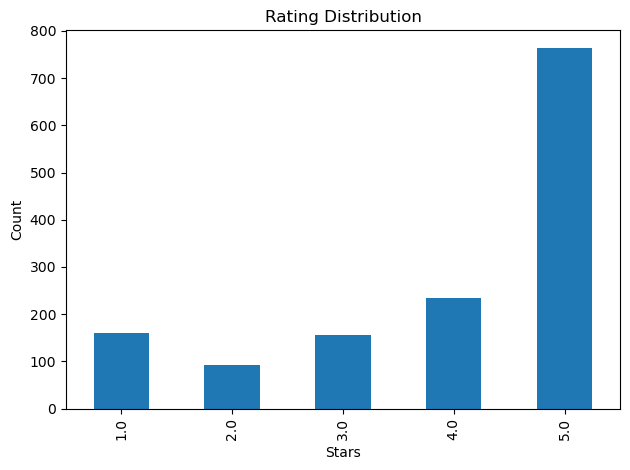

In [140]:
df_eda['rating'].value_counts().sort_index().plot(kind='bar', title='Rating Distribution')
plt.xlabel('Stars'); 
plt.ylabel('Count'); 
plt.tight_layout(); 
plt.show()

### Field selection and justification

Fields to KEEP for retrieval:

|Field|Source file|Why keep|
|---|---|---|
|text|review|Primary retrieval content — user-written review|
|title (review title)|review|Short query-style text, useful for matching|
|rating|review|Signal for relevance filtering|
|verified_purchase|review|Trust signal for ranking|
|helpful_vote|review|Proxy for review quality|
|product_title|metadata|Query-side matching|
|parent_asin|both|Key for document identity|
|description|meta|Rich product content for retrieval|
|features|meta|Structured product attributes|
|main_category|meta|Facet filtering|
|price|meta|Facet filtering|
|store|meta|Facet filtering|
|average_rating|meta|Product-level quality signal|

Fields to drop: 

|Field|Reason|
|---|---|
|timestamp|Temporal metadata not needed for semantic retrieval|
|user_id|User identity irrelevant for retrieval|
|asin|Redundant — parent_asin is the canonical product key|
|images (both files)|Binary/URL data, not useful for text retrieval|
|videos|Same as above|
|categories|Redundant with main_category unless we need multi-level taxonomy (is currently empty in our eda dataframe)|
|details|Semi-structured key-value dict — low signal, hard to index cleanly|
|rating_number|Product-level count, not meaningful per document|
|bought_together|Popularity signal, not retrieval-relevant|

In [ ]:
RETRIEVAL_FIELDS = [
    'parent_asin', 'text', 'title',        # review fields
    'rating', 'verified_purchase', 'helpful_vote',
    'product_title', 'description', 'features',  # meta fields
    'main_category', 'price', 'store', 'average_rating',
    'rating_bucket', 'len_tier'   
]
df_retrieval = df_eda[RETRIEVAL_FIELDS].dropna(subset=['text'])

### Text Preprocessing

Three transformations applied to the `text` field:

| Step | Decision | Rationale |
|---|---|---|
| Strip HTML tags | Remove `<br>`, `<b>` etc. | Some reviews contain raw HTML that adds noise |
| Lowercase | Normalize all text | Reduces vocabulary size; `Great` and `great` are the same token |
| Collapse whitespace | Trim and deduplicate spaces | Cleans artifacts from HTML removal |

Fields like `description` and `features` are kept raw in metadata — preprocessing is only applied to the `text` field used as `page_content` in retrieval.

In [142]:
# Confirm HTML tags exist in the data to justify the stripping step
df_eda[df_eda['text'].str.contains(r"<[^>]+>", regex=True, na=False)].head(3)

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,...,features,description,price,store,main_category,categories,details,bought_together,rating_bucket,len_tier
0,5.0,Little Richard ~ First Five Albums ~ 1957 - 1960,Here's little Richard's first five consecutive...,[],B0074B10ES,B0074B10ES,AGNUU44ETNXLBOUB53LJGFJP3SQA,1371827062000,37,False,...,[],[],NaN,Little Richard Format: Audio CD,Digital Music,[],{'Package Dimensions': '5.55 x 4.97 x 0.54 inc...,None,4.4-4.5,long
1,4.0,Worked well but not perfect.,[[VIDEOID:2f664d7f148abbb7155c0a1ca623024b]] S...,[],B01BBSGZIK,B01BBSGZIK,AHXCVPAFJ7GNO6TFJF6R3Z5FHMJQ,1459872103000,24,False,...,[],[],NaN,NaN,Digital Music,[],"{'Is Discontinued By Manufacturer': 'No', 'Pro...",None,4.4-4.5,long
2,5.0,A Remarkable Performance,Sir Colin Davis is known for his Berlioz recor...,[],B000GYHZ6M,B000GYHZ6M,AHAKK3WGQWSSVFSMHWSBPWHDETTQ,1263956849000,22,False,...,[],[PHILIPS -CLASSICS -2CD - more like new - EAN ...,20.38,"Various Artists (Contributor), Berlioz / ...",Digital Music,[],"{'Is Discontinued By Manufacturer': 'Yes', 'La...",None,4.4-4.5,long


In [143]:
# preprocessing function for text data
def preprocess_text(text: str) -> str:
    """
    Decisions:
    - Strip HTML tags (some reviews contain <br> etc.)
    - Lowercase for vocabulary normalization
    - Collapse whitespace
    """
    text = re.sub(r'<[^>]+>', ' ', str(text))   # remove HTML
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_retrieval = df_retrieval.copy()
df_retrieval['text_clean'] = df_retrieval['text'].apply(preprocess_text)
df_retrieval[['text', 'text_clean']].head()  # show before/after

,text,text_clean
0,Here's little Richard's first five consecutive...,here's little richard's first five consecutive...
1,[[VIDEOID:2f664d7f148abbb7155c0a1ca623024b]] S...,[[videoid:2f664d7f148abbb7155c0a1ca623024b]] s...
2,Sir Colin Davis is known for his Berlioz recor...,sir colin davis is known for his berlioz recor...
3,Track Listing:<br /><br />1. My Boyfriend's Ba...,track listing: 1. my boyfriend's back - the an...
4,This is an independent double album that was p...,this is an independent double album that was p...


### LangChain Document format

`features` and `description` are numpy.ndarray columns. LangChain's Document metadata must be JSON-serializable. `safe_metadata` function will fix any serialization error.

In [144]:
def safe_metadata(row, fields):
    result = {}
    for k in fields:
        if k == 'text':
            continue
        v = row[k]
        if isinstance(v, np.ndarray):
            v = v.tolist()
        result[k] = v
    return result

documents = [
    Document(
        page_content=row['text_clean'],
        metadata=safe_metadata(row, RETRIEVAL_FIELDS)
    )
    for _, row in df_retrieval.iterrows()
]

# Preview
print(documents[0].page_content[:300])
print(documents[0].metadata)

here's little richard's first five consecutive albums. starting with his 1957 debut to 1960. richard only had one more album prior 1962 (public domain) so it's interesting that "the king of gospel singers" which includes 12 more gospel songs, wasn't included here. richard's first charted r&b single 
{'parent_asin': 'B0074B10ES', 'title': 'Little Richard ~ First Five Albums ~ 1957 - 1960', 'rating': 5.0, 'verified_purchase': False, 'helpful_vote': 37, 'product_title': '5 Classic Albums Plus Bonus Singles', 'description': [], 'features': [], 'main_category': 'Digital Music', 'price': nan, 'store': 'Little Richard   Format: Audio CD', 'average_rating': 4.5, 'rating_bucket': '4.4-4.5', 'len_tier': 'long'}


## Summary

| Artifact | Path | Description |
|---|---|---|
| `reviews_raw.parquet` | `data/raw/` | First 20k review rows |
| `meta_raw.parquet` | `data/raw/` | First 20k metadata rows |
| `merged.parquet` | `data/processed/` | Full join of reviews + metadata |
| `stratified_sample.parquet` | `data/processed/` | Balanced sample (~1800 rows max) |

The `documents` list is ready for ingestion.
Each document's `page_content` is the cleaned review text, `metadata` carries all retrieval-relevant fields for filtering and ranking.